In [1]:
# [Cell 1] - Imports
import numpy as np
import pandas as pd
import tensorflow as tf
import ast
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input, Concatenate, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set display options to see all columns
pd.set_option('display.max_columns', None)

In [6]:
# [Cell 2] - Load Data
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\data_raw.csv"
df = pd.read_csv(data_path)

In [9]:
df.head()

,Unnamed: 0,text,happy,sad,disgusted,mad,scared,surprised,neutral,POS_Tags,TF_IDF,Sentiment_Score,Sentiment,Sentiment_Summary,Pretrained_Embeddings,Custom_Embeddings,Avg_Word_Length,Lexical_Density,Flesch_Score,Exclamation_Marks,Capitalized_Words,Numerics
0,0,That game hurt.,0,1,0,0,0,0,0,"[('That', 'DT'), ('game', 'NN'), ('hurt', 'VBD...",{'that': 1.0},-0.463350,Negative,TextBlob: Negative (-0.40) | VADER: Negative (...,"[0.042507488280534744, 0.03550424054265022, 0....",[-0.00695719 0.8561435 0.03211912 0.049696...,4.000000,0.666667,119.19,0,1,0
1,2,"You do right, if you don't care then fuck 'em!",0,0,0,0,0,0,1,"[('You', 'PRP'), ('do', 'VBP'), ('right', 'RB'...","{'do': 0.3759313245541707, 'don': 0.3616786161...",0.012229,Neutral,TextBlob: Negative (-0.11) | VADER: Positive (...,"[0.07499919086694717, -0.02374253422021866, 0....",[ 0.72163534 0.9013793 -1.266749 -0.115555...,3.222222,0.333333,112.09,1,1,0
2,3,Man I love reddit.,1,0,0,0,0,0,0,"[('Man', 'NN'), ('I', 'PRP'), ('love', 'VBP'),...",{'love': 1.0},0.568450,Positive,TextBlob: Positive (0.50) | VADER: Positive (0...,"[-0.06888318061828613, -0.0226387158036232, 0....",[-0.7542339 0.5780688 0.11816424 0.945814...,3.500000,0.750000,92.80,0,1,0
3,4,"[NAME] was nowhere near them, he was by the Fa...",0,0,0,0,0,0,1,"[('[', 'NN'), ('NAME', 'NNP'), (']', 'NNP'), (...","{'by': 0.4390266667081936, 'he': 0.33944814194...",0.050000,Neutral,TextBlob: Positive (0.10) | VADER: Neutral (0....,"[0.03852083906531334, 0.10962970554828644, -0....",[ 1.5900852e-02 6.8748605e-01 -1.5371421e-01 ...,3.800000,0.200000,95.17,0,1,0
4,5,Right? Considering it’s such an important docu...,1,0,0,0,0,0,0,"[('Right', 'RB'), ('?', '.'), ('Considering', ...","{'an': 0.3872438248982594, 'and': 0.2366671590...",0.428914,Positive,TextBlob: Positive (0.23) | VADER: Positive (0...,"[-0.038964465260505676, 0.10193052142858505, -...",[ 0.15606754 0.97362524 -0.49129793 0.336218...,5.095238,0.523810,69.28,1,2,0


In [ ]:
# [Cell 3] - Feature Preparation (Updated)
# Process text data
texts = df['text'].astype(str).tolist()
max_num_words = 10000
max_sequence_length = 100

# Tokenize text
tokenizer = Tokenizer(num_words=max_num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X_text = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# Process Sentiment_Score (numerical)
X_sentiment_score = df['Sentiment_Score'].values.reshape(-1, 1)
scaler = StandardScaler()
X_sentiment_score_scaled = scaler.fit_transform(X_sentiment_score)

# Process Sentiment (categorical)
# Check scikit-learn version and use appropriate parameters
import sklearn
from packaging import version

if version.parse(sklearn.__version__) >= version.parse('0.22'):
    # For newer versions of scikit-learn
    encoder = OneHotEncoder(sparse_output=False)
else:
    # For older versions of scikit-learn
    encoder = OneHotEncoder(sparse=False)

# If that still doesn't work, use this alternative approach
try:
    X_sentiment_encoded = encoder.fit_transform(df['Sentiment'].values.reshape(-1, 1))
except TypeError:
    # Alternative approach using pandas get_dummies
    X_sentiment_encoded = pd.get_dummies(df['Sentiment']).values

# Process POS_Tags
# Convert string representation of list to actual list
def process_pos_tags(pos_tags_str):
    try:
        # Parse the string representation of the list
        pos_tags = ast.literal_eval(pos_tags_str)
        # Extract just the POS tag part (assuming format is [(word, tag), ...])
        return [tag for _, tag in pos_tags]
    except:
        return []

# Create a tokenizer for POS tags
pos_tags_list = [process_pos_tags(tags) for tags in df['POS_Tags']]
pos_tokenizer = Tokenizer()
pos_tokenizer.fit_on_texts(pos_tags_list)
pos_sequences = pos_tokenizer.texts_to_sequences(pos_tags_list)
X_pos_tags = pad_sequences(pos_sequences, maxlen=max_sequence_length, padding='post')

# Process embeddings (assuming they're stored as string representations of lists)
def process_embeddings(embedding_str):
    try:
        # Parse the string representation of the list
        embedding = ast.literal_eval(embedding_str)
        return embedding
    except:
        return [0.0] * 100  # Default empty embedding

# Process Custom_Embeddings
custom_embeddings = np.array([process_embeddings(emb) for emb in df['Custom_Embeddings']])
# If embeddings are variable length, you might need to pad them
# For simplicity, we'll assume they're all the same length

# Process Pretrained_Embeddings
pretrained_embeddings = np.array([process_embeddings(emb) for emb in df['Pretrained_Embeddings']])

# Prepare labels
emotion_cols = ['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral']
labels = df[emotion_cols].values
y = np.argmax(labels, axis=1)
y_cat = to_categorical(y, num_classes=len(emotion_cols))

In [12]:
# [Cell 4] - Train/Validation/Test Split (70-20-10)
# First split into train and temp (70-30)
X_train_text, X_temp_text, X_train_pos, X_temp_pos, X_train_sent_score, X_temp_sent_score, \
X_train_sent_cat, X_temp_sent_cat, X_train_custom_emb, X_temp_custom_emb, \
X_train_pretrained_emb, X_temp_pretrained_emb, y_train, y_temp = train_test_split(
    X_text, X_pos_tags, X_sentiment_score_scaled, X_sentiment_encoded, 
    custom_embeddings, pretrained_embeddings, y_cat,
    test_size=0.3, random_state=42
)

# Split temp into validation and test (20-10 of total)
X_val_text, X_test_text, X_val_pos, X_test_pos, X_val_sent_score, X_test_sent_score, \
X_val_sent_cat, X_test_sent_cat, X_val_custom_emb, X_test_custom_emb, \
X_val_pretrained_emb, X_test_pretrained_emb, y_val, y_test = train_test_split(
    X_temp_text, X_temp_pos, X_temp_sent_score, X_temp_sent_cat,
    X_temp_custom_emb, X_temp_pretrained_emb, y_temp,
    test_size=0.33, random_state=42
)

In [13]:
# [Cell 5] - Build Multi-Input RNN Model
# Text input branch
text_input = Input(shape=(max_sequence_length,), name='text_input')
embedding = Embedding(input_dim=min(max_num_words, len(tokenizer.word_index) + 1),
                     output_dim=32,
                     input_length=max_sequence_length)(text_input)
rnn_text = SimpleRNN(64, return_sequences=False)(embedding)

# POS tags input branch
pos_input = Input(shape=(max_sequence_length,), name='pos_input')
pos_embedding = Embedding(input_dim=len(pos_tokenizer.word_index) + 1,
                         output_dim=16,
                         input_length=max_sequence_length)(pos_input)
rnn_pos = SimpleRNN(32, return_sequences=False)(pos_embedding)

# Sentiment score input
sent_score_input = Input(shape=(1,), name='sentiment_score_input')
sent_score_dense = Dense(8, activation='relu')(sent_score_input)

# Sentiment category input
sent_cat_input = Input(shape=(X_sentiment_encoded.shape[1],), name='sentiment_cat_input')
sent_cat_dense = Dense(8, activation='relu')(sent_cat_input)

# Custom embeddings input
custom_emb_input = Input(shape=(custom_embeddings.shape[1],), name='custom_emb_input')
custom_emb_dense = Dense(16, activation='relu')(custom_emb_input)

# Pretrained embeddings input
pretrained_emb_input = Input(shape=(pretrained_embeddings.shape[1],), name='pretrained_emb_input')
pretrained_emb_dense = Dense(16, activation='relu')(pretrained_emb_input)

# Combine all features
combined = Concatenate()([
    rnn_text, 
    rnn_pos, 
    sent_score_dense, 
    sent_cat_dense,
    custom_emb_dense,
    pretrained_emb_dense
])

# Dense layers
x = Dense(128, activation='relu')(combined)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(len(emotion_cols), activation='softmax')(x)

# Create and compile model
model = Model(
    inputs=[
        text_input, 
        pos_input, 
        sent_score_input, 
        sent_cat_input,
        custom_emb_input,
        pretrained_emb_input
    ], 
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 pos_input (InputLayer)         [(None, 100)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 100, 32)      320000      ['text_input[0][0]']             
                                                                                                  
 embedding_1 (Embedding)        (None, 100, 16)      736         ['pos_input[0][0]']              
                                                                                              

In [14]:
# [Cell 6] - Train Model
history = model.fit(
    [
        X_train_text, 
        X_train_pos, 
        X_train_sent_score, 
        X_train_sent_cat,
        X_train_custom_emb,
        X_train_pretrained_emb
    ],
    y_train,
    validation_data=(
        [
            X_val_text, 
            X_val_pos, 
            X_val_sent_score, 
            X_val_sent_cat,
            X_val_custom_emb,
            X_val_pretrained_emb
        ], 
        y_val
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
3759/3759 [==============================] - 55s 14ms/step - loss: 1.3207 - accuracy: 0.4892 - val_loss: 1.2770 - val_accuracy: 0.5000
Epoch 2/10
3759/3759 [==============================] - 53s 14ms/step - loss: 1.2702 - accuracy: 0.5085 - val_loss: 1.2538 - val_accuracy: 0.5083
Epoch 3/10
3759/3759 [==============================] - 52s 14ms/step - loss: 1.2534 - accuracy: 0.5132 - val_loss: 1.2448 - val_accuracy: 0.5119
Epoch 4/10
3759/3759 [==============================] - 54s 14ms/step - loss: 1.2477 - accuracy: 0.5143 - val_loss: 1.2450 - val_accuracy: 0.5092
Epoch 5/10
3759/3759 [==============================] - 53s 14ms/step - loss: 1.2400 - accuracy: 0.5164 - val_loss: 1.2377 - val_accuracy: 0.5123
Epoch 6/10
3759/3759 [==============================] - 54s 14ms/step - loss: 1.2348 - accuracy: 0.5182 - val_loss: 1.2347 - val_accuracy: 0.5139
Epoch 7/10
3759/3759 [==============================] - 56s 15ms/step - loss: 1.2299 - accuracy: 0.5200 - val_loss: 1.2352 -

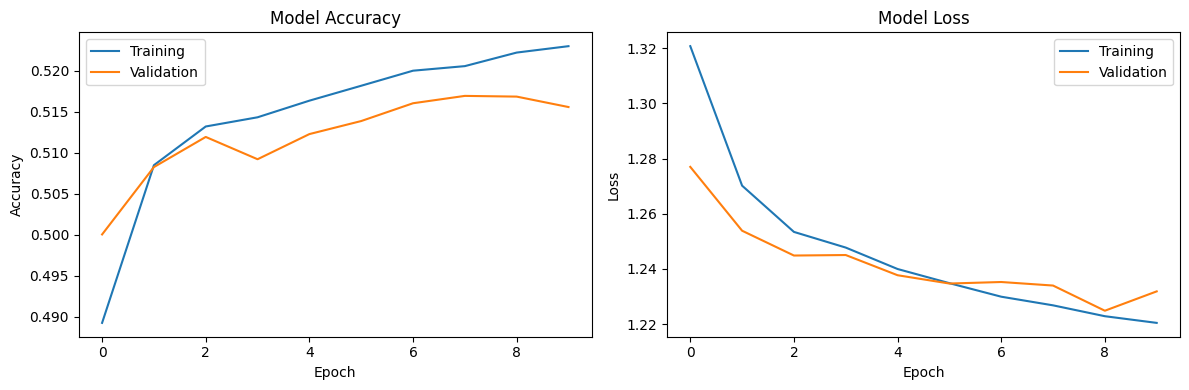

In [15]:
# [Cell 7] - Evaluate Model
# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

532/532 [==============================] - 2s 4ms/step

Test Set Metrics:
Accuracy: 0.5223
Precision: 0.5261
Recall: 0.5223
F1 Score: 0.4919


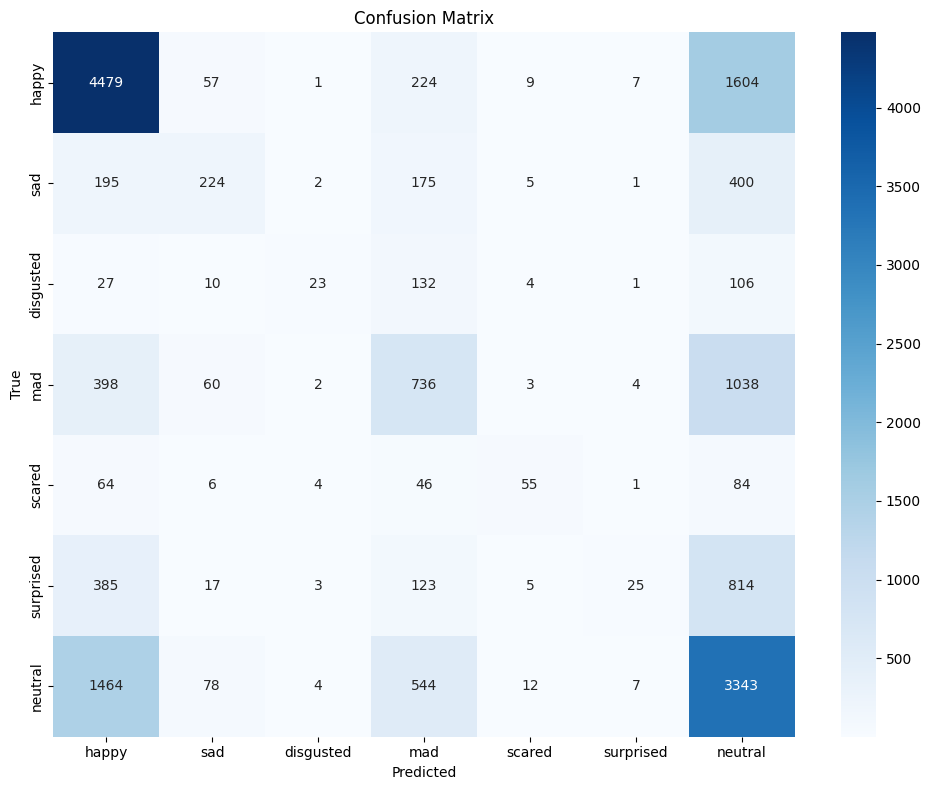

In [16]:
# Evaluate on test set
y_pred = model.predict([
    X_test_text, 
    X_test_pos, 
    X_test_sent_score, 
    X_test_sent_cat,
    X_test_custom_emb,
    X_test_pretrained_emb
])
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')

print("\nTest Set Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_cols, 
            yticklabels=emotion_cols)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()



In [17]:
# [Cell 8] - Save Model
model.save("rnn_model_v1.h5")